# Data Processing

This notebook prepares the data used throughout the project for the
psychological defense detection task. It loads the raw dialogue data,
builds the train / validation / test splits, applies a data augmentation
step to mitigate class imbalance, and organizes the resulting samples
into the subsets required by the different modeling approaches.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datasets
from datasets import Dataset, concatenate_datasets, load_from_disk
from collections import Counter

DATA_PATH = "/content/drive/MyDrive/{hide}"
random.seed(42)



#Subsets creation

In [ ]:
train_path = os.path.join(DATA_PATH, "train.json")
test_path = os.path.join(DATA_PATH, "test.json")

train_data = datasets.load_dataset("json", data_files=train_path)["train"]
test_data = datasets.load_dataset("json", data_files=test_path)["train"]


#creation val subset
n_per_class=15
labels = set(train_data["label"])

val_subsets = []
train_subsets = []

for label in labels:
    # Filter dataset by label
    label_dataset = train_data.filter(
        lambda x: x["label"] == label
    )

    label_dataset = label_dataset.shuffle(seed=42)

    val_subset = label_dataset.select(range(n_per_class))
    train_subset = label_dataset.select(
        range(n_per_class, len(label_dataset))
    )

    val_subsets.append(val_subset)
    train_subsets.append(train_subset)

val_dataset = concatenate_datasets(val_subsets)
new_train_dataset = concatenate_datasets(train_subsets)

val_data = val_dataset.shuffle(seed=42)
train_data = new_train_dataset.shuffle(seed=42)




Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Filter:   0%|          | 0/1864 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1864 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1864 [00:00<?, ? examples/s]

...

Filter:   0%|          | 0/1864 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1864 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1864 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1864 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1864 [00:00<?, ? examples/s]

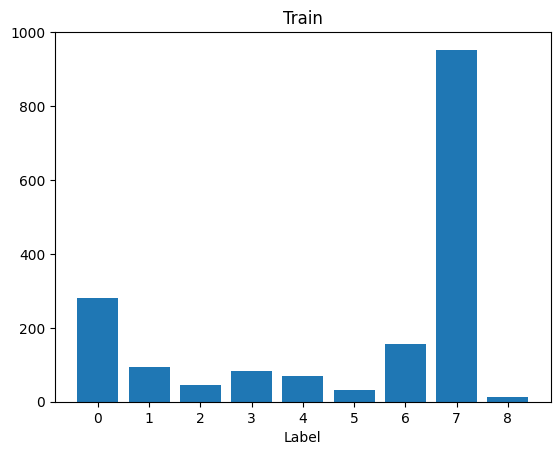

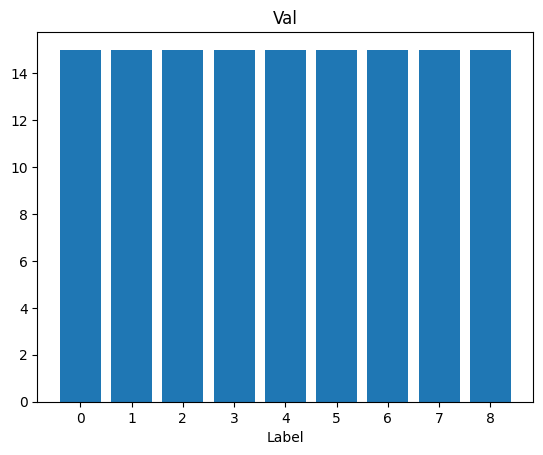

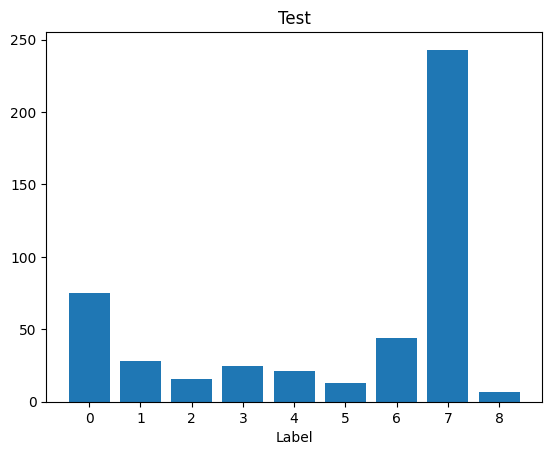

In [ ]:
def get_label_distribution(dataset):
    labels = [item["label"] for item in dataset]
    label_counts = Counter(labels)
    return dict(label_counts)

def plot_distribution(counter, title):
    labels = list(range(9))
    counts = [counter.get(i, 0) for i in labels]
    plt.bar(labels, counts)
    plt.title(title)
    plt.xticks(labels)
    plt.xlabel("Label")
    plt.show()

plot_distribution(get_label_distribution(train_data), "Train")
plot_distribution(get_label_distribution(val_data), "Val")
plot_distribution(get_label_distribution(test_data), "Test")

##Augmentation

In [ ]:
def get_last_seeker_text(dialogue):
    seeker_turns = [t["text"] for t in dialogue if t["speaker"] == "seeker"]
    return seeker_turns[-1] if seeker_turns else ""


# Adjust artificial samples format
def load_augmentation_csv(csv_path, id_prefix="aug"):
    df = pd.read_csv(csv_path)

    samples = []
    for i, row in df.iterrows():
        dialogue = json.loads(row["dialogue"])
        sample_id = f"{id_prefix}_{i:05d}"
        samples.append({
            "id": sample_id,
            "dialogue_id": sample_id,
            "dialogue": dialogue,
            "current_text": get_last_seeker_text(dialogue),
            "label": int(row["label"]),
        })

    print(f"Formatted {len(samples)} sample")
    return samples

#Load pre-formatted samples
def augment_dataset(train_data, csv_paths, id_prefix="aug"):
    augmented = list(train_data)
    counter = 0

    for csv_path in csv_paths:
        df = pd.read_csv(csv_path)
        for _, row in df.iterrows():
            dialogue = json.loads(row["dialogue"])
            sample_id = f"{id_prefix}_{counter:05d}"
            augmented.append({
                "id": sample_id,
                "dialogue_id": sample_id,
                "dialogue": dialogue,
                "current_text": get_last_seeker_text(dialogue),
                "label": int(row["label"]),
            })
            counter += 1

    print(f"Total added samples: {counter}")
    print(f"Final dataset: {len(augmented)}")
    return augmented

def save_dataset(data, path):
    with open(path, "w", encoding="utf-8") as f:
        for sample in data:
            f.write(json.dumps(sample, ensure_ascii=False) + "\n")
    print(f"Saved")



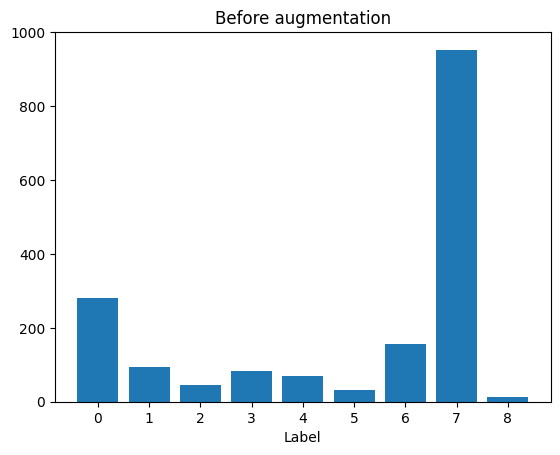

Total added samples: 116
Final dataset: 1845


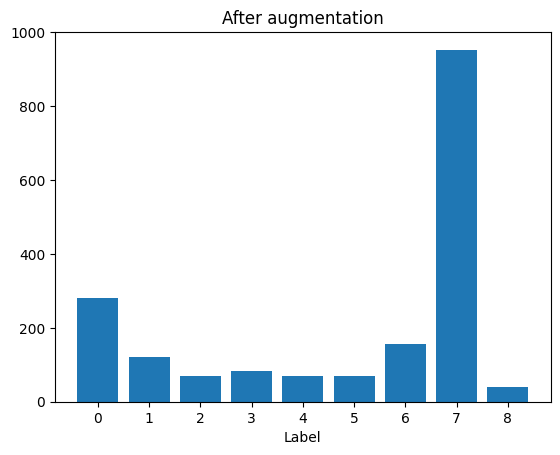

In [ ]:
plot_distribution(get_label_distribution(train_data), "Before augmentation")

augmentation_csvs = ["/content/drive/MyDrive/PsyDefDetect/data/augmentation.csv",]

train_final = augment_dataset(train_data, augmentation_csvs, id_prefix="aug")

plot_distribution(get_label_distribution(train_final), "After augmentation")


In [ ]:
train_final_dataset = Dataset.from_list(train_final)
#train_final_dataset.save_to_disk(os.path.join(DATA_PATH,"split/train"))
#val_data.save_to_disk(os.path.join(DATA_PATH,"split/val"))
#test_data.save_to_disk(os.path.join(DATA_PATH,"split/test"))

#Nodes splitting

In [ ]:
train_data = datasets.load_from_disk(os.path.join(DATA_PATH,"split/train"))
val_data = datasets.load_from_disk(os.path.join(DATA_PATH,"split/val"))
test_data = datasets.load_from_disk(os.path.join(DATA_PATH,"split/test"))

In [ ]:
t#N1 - prima divisione tra   Non_defense, defense , ambiguous

n1_train = train_data.filter(lambda d: d["label"] in [0,1,2,3,4,5,6,7,8])
n1_val = val_data.filter(lambda d: d["label"] in [0,1,2,3,4,5,6,7,8])
n1_mapping = {
    0: 0,
    8: 1,
    1: 2, 2: 2, 3: 2, 4: 2, 5: 2, 6: 2, 7: 2,
}
n1_train_mapped = n1_train.map(lambda x: {"label": n1_mapping.get(x["label"], x["label"])})
n1_val_mapped = n1_val.map(lambda x: {"label": n1_mapping.get(x["label"], x["label"])})

#N2 - divisione tra gruppi di difesa
print("N2")
n2_train = train_data.filter(lambda d: d["label"] in [1,2,3,4,5,6,7])
n2_val = val_data.filter(lambda d: d["label"] in [1,2,3,4,5,6,7])
n2_mapping = {1: 0,
              2: 1, 4: 1,
              3: 2, 5: 2,
              6: 3,
              7: 4}
n2_train_mapped = n2_train.map(lambda x: {"label": n2_mapping.get(x["label"], x["label"])})
n2_val_mapped = n2_val.map(lambda x: {"label": n2_mapping.get(x["label"], x["label"])})


#N3 - image distortion defense
print("N3")
n3_train = train_data.filter(lambda d: d["label"] in [2,4])
n3_val = val_data.filter(lambda d: d["label"] in [2,4])
n3_mapping = {2: 0, 4: 1}
n3_train_mapped = n3_train.map(lambda x: {"label": n3_mapping.get(x["label"], x["label"])})
n3_val_mapped = n3_val.map(lambda x: {"label": n3_mapping.get(x["label"], x["label"])})

#N4 - reality avoidance
print("N4")
n4_train = train_data.filter(lambda d: d["label"] in [3,5])
n4_val = val_data.filter(lambda d: d["label"] in [3,5])
n4_mapping = {3: 0, 5: 1}
n4_train_mapped = n4_train.map(lambda x: {"label": n4_mapping.get(x["label"], x["label"])})
n4_val_mapped = n4_val.map(lambda x: {"label": n4_mapping.get(x["label"], x["label"])})


Filter:   0%|          | 0/1092 [00:00<?, ? examples/s]

Filter:   0%|          | 0/135 [00:00<?, ? examples/s]

Map:   0%|          | 0/1092 [00:00<?, ? examples/s]

Map:   0%|          | 0/135 [00:00<?, ? examples/s]

N2
N3
N4


In [ ]:
n1_train_mapped.save_to_disk(os.path.join(DATA_PATH,"node/noaugmented/n1_train"))
n1_val_mapped.save_to_disk(os.path.join(DATA_PATH,"node/noaugmented/n1_val"))

n2_train_mapped.save_to_disk(os.path.join(DATA_PATH,"node/noaugmented/n2_train"))
n2_val_mapped.save_to_disk(os.path.join(DATA_PATH,"node/noaugmented/n2_val"))

n3_train_mapped.save_to_disk(os.path.join(DATA_PATH,"node/noaugmented/n3_train"))
n3_val_mapped.save_to_disk(os.path.join(DATA_PATH,"node/noaugmented/n3_val"))

n4_train_mapped.save_to_disk(os.path.join(DATA_PATH,"node/noaugmented/n4_train"))
n4_val_mapped.save_to_disk(os.path.join(DATA_PATH,"node/noaugmented/n4_val"))

Saving the dataset (0/1 shards):   0%|          | 0/1805 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/120 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1524 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/105 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/140 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/30 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/154 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/30 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/175 [00:00<?, ? examples/s]